# 05 — Subgroup & Fairness Analysis

**Phase 4: Does the model perform equally well across clinically meaningful subgroups?**

A model with 0.46 average AUC-PR is useful — but if it works great on 80 % of patients and fails on the other 20 %, that's a problem. This notebook breaks performance down by:

1. **Sepsis** (yes / no) — clinically the most important subgroup. Sepsis patients are high-acuity, longer stays.
2. **Age group** (18-40, 40-65, 65-80, 80+) — physiology and recovery differ by age.
3. **Gender** (Male / Female) — fairness axis required by clinical AI guidelines.
4. **Race** (White / Black / Hispanic / Asian / Other) — the most critical fairness axis in clinical AI.
5. **Insurance** (Medicare / Medicaid / Private / Other) — SES proxy in US healthcare data.

**Sections:**
1. Setup + subgroup definitions
2. Sepsis subgroup performance (regression + classification)
3. Sepsis subgroup SHAP analysis + top-10 feature comparison
4. Age group performance
5. Gender performance
5b. Race performance
5c. Insurance performance
6. Fairness disparity table — all 5 axes side-by-side

In [1]:
SOURCE = "mimic4"

import sys, warnings
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    average_precision_score, roc_auc_score, f1_score, accuracy_score,
)

from src.config import FIGURES_DIR, MODELS_DIR, RANDOM_SEED, TARGET
from src.data.load import load_icu_stays
from src.features.build import split_xy
from src.models.train import prepare_target, to_days, LONG_STAY_DAYS

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

df = load_icu_stays(SOURCE)
print(f"Cohort: {len(df):,} stays  |  Sepsis prevalence: {df['has_sepsis'].mean():.1%}")
print(f"Gender split: {(df['gender']=='M').sum():,} M / {(df['gender']=='F').sum():,} F")

X, y_raw, numeric_cols, categorical_cols = split_xy(df)
y_reg = prepare_target(y_raw, "regression")
y_clf = prepare_target(y_raw, "classification")

X_tr, X_te, y_tr_reg, y_te_reg, idx_tr, idx_te = train_test_split(
    X, y_reg, df.index, test_size=0.2, random_state=RANDOM_SEED,
)
X_tr_c, X_te_c, y_tr_clf, y_te_clf, idx_tr_c, idx_te_c = train_test_split(
    X, y_clf, df.index, test_size=0.2, random_state=RANDOM_SEED, stratify=y_clf,
)

y_te_reg_arr = y_te_reg.values
y_te_clf_arr = y_te_clf.values
y_te_days = to_days(y_te_reg_arr, "regression")

# All subgroup metadata in one DataFrame per task
META_COLS = ["has_sepsis", "age", "gender", "admission_type", "race", "insurance"]
te_meta_reg = df.loc[idx_te, META_COLS].reset_index(drop=True)
te_meta_clf = df.loc[idx_te_c, META_COLS].reset_index(drop=True)

age_bins = [18, 40, 65, 80, 200]
age_labels = ["18-40", "40-65", "65-80", "80+"]
te_meta_reg["age_group"] = pd.cut(te_meta_reg["age"], bins=age_bins, labels=age_labels, right=False)
te_meta_clf["age_group"] = pd.cut(te_meta_clf["age"], bins=age_bins, labels=age_labels, right=False)

MODEL_NAMES = ["linear", "rf", "xgb", "lgbm"]
reg_pipes = {m: joblib.load(MODELS_DIR / f"{m}_regression_{SOURCE}.joblib") for m in MODEL_NAMES}
clf_pipes = {m: joblib.load(MODELS_DIR / f"{m}_classification_{SOURCE}.joblib") for m in MODEL_NAMES}

print(f"\nTest set sizes:")
print(f"  Regression test: {len(X_te):,}")
print(f"  Classification test: {len(X_te_c):,}")

Cohort: 48,222 stays  |  Sepsis prevalence: 13.8%
Gender split: 27,548 M / 20,674 F



Test set sizes:
  Regression test: 9,645
  Classification test: 9,645


## 2. Sepsis subgroup performance

Do the models predict equally well for sepsis vs non-sepsis patients?

**Clinical context:** Sepsis patients are high-acuity and stay longer on average (clinical literature: median LoS ~7-10 days vs 2-3 days for non-sepsis). The model may either:
- Perform **worse** on sepsis (their LoS varies more, harder to predict)
- Perform **better** on sepsis (their long stays are easier to flag — clear acuity signals)

Regression: MAE + actual mean LoS + relative error per sepsis subgroup
(MAE/actual_mean shows how big the error is relative to typical stay length)


N  actual_mean_LoS   MAE  MAE / actual_mean (%)
model  subgroup                                                      
LINEAR non-sepsis  8319             3.61  2.03                  56.18
       sepsis      1326             6.73  4.31                  64.13
RF     non-sepsis  8319             3.61  1.95                  53.96
       sepsis      1326             6.73  4.16                  61.83
XGB    non-sepsis  8319             3.61  1.88                  52.06
       sepsis      1326             6.73  3.98                  59.13
LGBM   non-sepsis  8319             3.61  1.88                  52.02
       sepsis      1326             6.73  3.98                  59.10

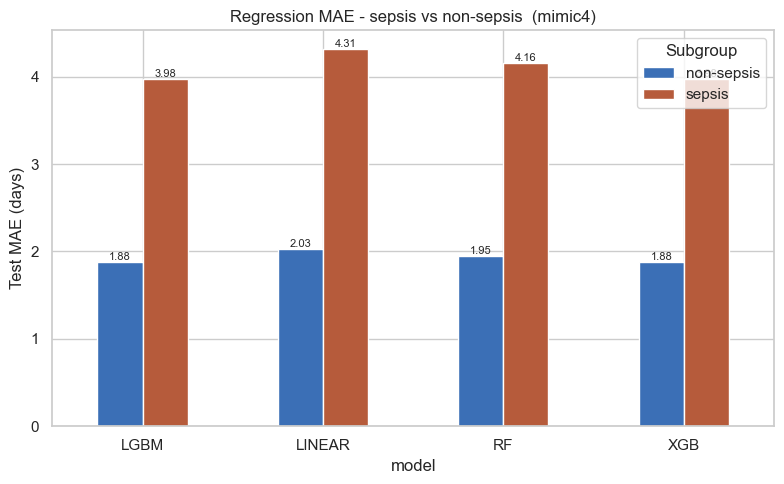

In [2]:
# Regression: MAE per sepsis subgroup
reg_rows = []
for m in MODEL_NAMES:
    pipe = reg_pipes[m]
    preds_days = to_days(pipe.predict(X_te), "regression")
    for sepsis_val, sepsis_label in [(0, "non-sepsis"), (1, "sepsis")]:
        mask = (te_meta_reg["has_sepsis"] == sepsis_val).values
        if mask.sum() == 0:
            continue
        mae = mean_absolute_error(y_te_days[mask], preds_days[mask])
        rmse = np.sqrt(mean_squared_error(y_te_days[mask], preds_days[mask]))
        actual_mean = y_te_days[mask].mean()
        reg_rows.append({
            "model": m.upper(), "subgroup": sepsis_label,
            "N": mask.sum(), "actual_mean_LoS": actual_mean,
            "MAE": mae, "RMSE": rmse,
            "MAE / actual_mean (%)": 100 * mae / actual_mean,
        })

reg_df = pd.DataFrame(reg_rows)
# Combined table: MAE, actual mean LoS, and relative MAE in one view
combined = reg_df.set_index(["model", "subgroup"])[["N", "actual_mean_LoS", "MAE", "MAE / actual_mean (%)"]].round(2)
print("Regression: MAE + actual mean LoS + relative error per sepsis subgroup")
print("(MAE/actual_mean shows how big the error is relative to typical stay length)")
display(combined)

fig, ax = plt.subplots(figsize=(8, 5))
pivot = reg_df.pivot(index="model", columns="subgroup", values="MAE")
pivot.plot.bar(ax=ax, color=["#3b6fb6", "#b65b3b"])
ax.set_ylabel("Test MAE (days)")
ax.set_title(f"Regression MAE - sepsis vs non-sepsis  ({SOURCE})")
ax.legend(title="Subgroup")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"subgroup_sepsis_regression_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

Classification AUC-PR by sepsis subgroup:


subgroup,non-sepsis,sepsis
model,,
LGBM,0.365,0.654
LINEAR,0.282,0.537
RF,0.326,0.632
XGB,0.371,0.660



Long-stay share (>=7d) per subgroup:


subgroup,non-sepsis,sepsis
model,,
LGBM,0.105,0.267
LINEAR,0.105,0.267
RF,0.105,0.267
XGB,0.105,0.267


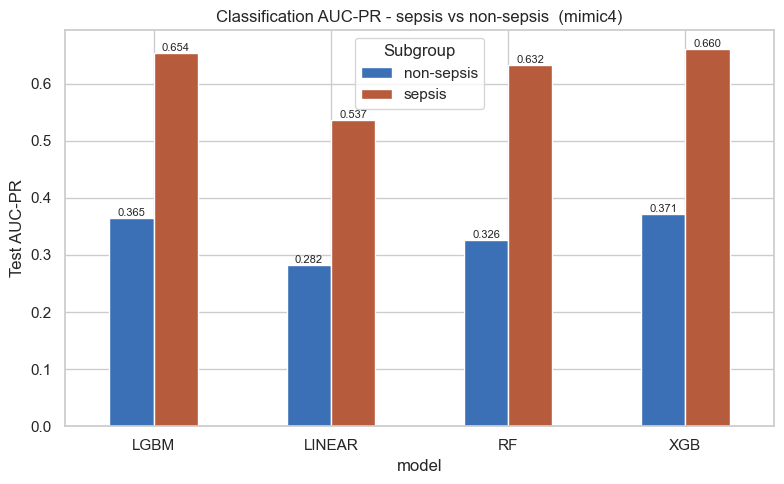

In [3]:
# Classification: AUC-PR + F1 per sepsis subgroup
clf_rows = []
for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    y_pred = pipe.predict(X_te_c)
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    for sepsis_val, sepsis_label in [(0, "non-sepsis"), (1, "sepsis")]:
        mask = (te_meta_clf["has_sepsis"] == sepsis_val).values
        if mask.sum() == 0 or len(np.unique(y_te_clf_arr[mask])) < 2:
            continue
        auc_pr = average_precision_score(y_te_clf_arr[mask], y_proba[mask])
        auc_roc = roc_auc_score(y_te_clf_arr[mask], y_proba[mask])
        f1 = f1_score(y_te_clf_arr[mask], y_pred[mask])
        long_share = y_te_clf_arr[mask].mean()
        clf_rows.append({
            "model": m.upper(), "subgroup": sepsis_label,
            "N": mask.sum(), "long_share": long_share,
            "AUC_PR": auc_pr, "AUC_ROC": auc_roc, "F1": f1,
        })

clf_df = pd.DataFrame(clf_rows)
print("Classification AUC-PR by sepsis subgroup:")
display(clf_df.pivot(index="model", columns="subgroup", values="AUC_PR").round(3))
print("\nLong-stay share (>=7d) per subgroup:")
display(clf_df.pivot(index="model", columns="subgroup", values="long_share").round(3))

fig, ax = plt.subplots(figsize=(8, 5))
pivot = clf_df.pivot(index="model", columns="subgroup", values="AUC_PR")
pivot.plot.bar(ax=ax, color=["#3b6fb6", "#b65b3b"])
ax.set_ylabel("Test AUC-PR")
ax.set_title(f"Classification AUC-PR - sepsis vs non-sepsis  ({SOURCE})")
ax.legend(title="Subgroup")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"subgroup_sepsis_classification_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Sepsis subgroup SHAP analysis

Are the **same features** important for sepsis patients as for non-sepsis? If not, the model may be relying on different signals for each group.

We compute SHAP separately for sepsis and non-sepsis test patients (XGB regression, the strongest model).

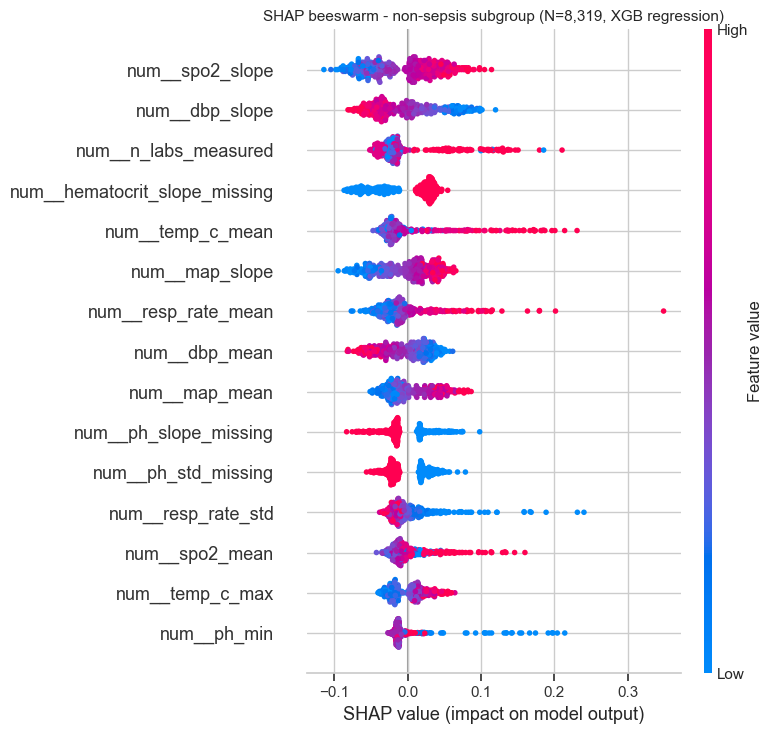

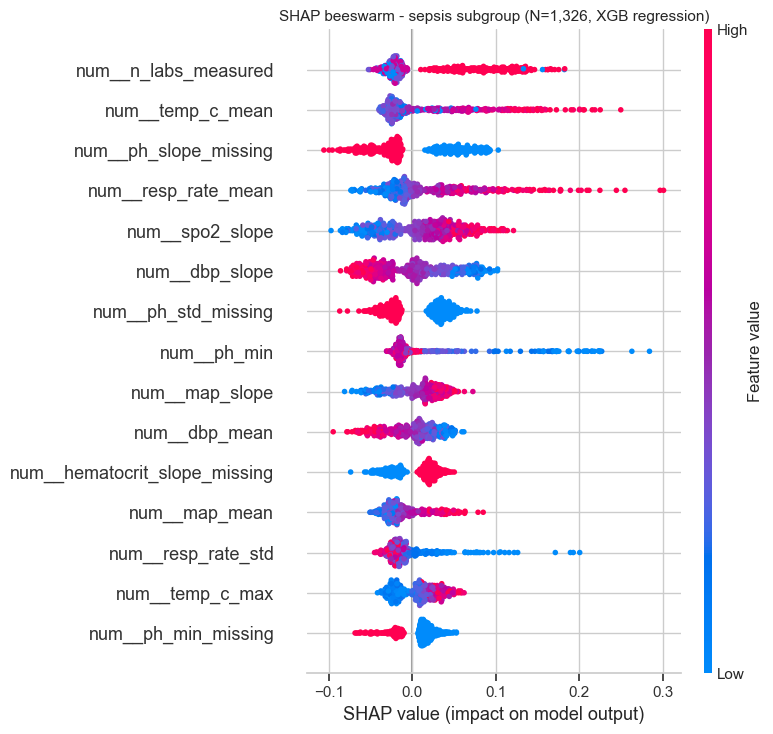

In [4]:
# SHAP on sepsis vs non-sepsis test patients (XGB regression)
# Plotted as TWO separate full-width figures (side-by-side cramps the x-axis)
pipe = reg_pipes["xgb"]
preprocessor = pipe.named_steps["preprocess"]
estimator = pipe.named_steps["model"]
feature_names = list(preprocessor.get_feature_names_out())

X_te_trans = preprocessor.transform(X_te)
explainer = shap.TreeExplainer(estimator)

rng = np.random.RandomState(RANDOM_SEED)
sepsis_shap_results = {}

for sepsis_val, sepsis_label in [(0, "non-sepsis"), (1, "sepsis")]:
    mask = (te_meta_reg["has_sepsis"] == sepsis_val).values
    X_sub = X_te_trans[mask]
    n_sample = min(500, len(X_sub))
    idx = rng.choice(len(X_sub), size=n_sample, replace=False)
    sv = explainer(X_sub[idx])
    sv.feature_names = feature_names
    sepsis_shap_results[sepsis_label] = sv

    # Each subgroup gets its own full-width figure for readability
    plt.figure(figsize=(11, 7))
    shap.summary_plot(sv, X_sub[idx], feature_names=feature_names, show=False, max_display=15)
    plt.title(f"SHAP beeswarm - {sepsis_label} subgroup (N={mask.sum():,}, XGB regression)", fontsize=11)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_{sepsis_label}_{SOURCE}.png", dpi=120, bbox_inches="tight")
    plt.show()

In [5]:
# Top-10 SHAP feature comparison: sepsis vs non-sepsis
# Helper: normalize transformed feature names back to raw column names
def _normalize_imp(imp_series, cat_cols):
    result = {}
    for fname, val in imp_series.items():
        if fname.startswith("num__"):
            base = fname[5:]
        elif fname.startswith("cat__"):
            base = next((cc for cc in cat_cols if fname.startswith(f"cat__{cc}_")), fname[5:])
        else:
            base = fname
        result[base] = result.get(base, 0) + abs(val)
    return pd.Series(result).sort_values(ascending=False)

ns_sv = sepsis_shap_results["non-sepsis"]
s_sv = sepsis_shap_results["sepsis"]

ns_imp = pd.Series(np.abs(ns_sv.values).mean(axis=0), index=feature_names).sort_values(ascending=False)
s_imp = pd.Series(np.abs(s_sv.values).mean(axis=0), index=feature_names).sort_values(ascending=False)

ns_top = _normalize_imp(ns_imp, categorical_cols).head(10)
s_top = _normalize_imp(s_imp, categorical_cols).head(10)

# Side-by-side top-10
top_table = pd.DataFrame({
    "rank": range(1, 11),
    "non-sepsis (top 10)": ns_top.index.tolist(),
    "non-sepsis mean|SHAP|": ns_top.values.round(4),
    "sepsis (top 10)": s_top.index.tolist(),
    "sepsis mean|SHAP|": s_top.values.round(4),
}).set_index("rank")

print("Top-10 features per sepsis subgroup (XGB regression, normalized names):")
display(top_table)

# Overlap
overlap = set(ns_top.index) & set(s_top.index)
only_ns = set(ns_top.index) - set(s_top.index)
only_s = set(s_top.index) - set(ns_top.index)
print(f"\nOverlap: {len(overlap)}/10 features shared between sepsis and non-sepsis top-10")
print(f"  Shared: {sorted(overlap)}")
print(f"  Only in non-sepsis top-10: {sorted(only_ns)}")
print(f"  Only in sepsis top-10: {sorted(only_s)}")

top_table.to_csv(FIGURES_DIR.parent / "tables" / f"sepsis_top10_comparison_{SOURCE}.csv")
print(f"\nSaved to reports/tables/sepsis_top10_comparison_{SOURCE}.csv")

Top-10 features per sepsis subgroup (XGB regression, normalized names):


,non-sepsis (top 10),non-sepsis mean|SHAP|,sepsis (top 10),sepsis mean|SHAP|
rank,,,,
1,admission_type,0.0501,n_labs_measured,0.0550
2,spo2_slope,0.0410,temp_c_mean,0.0444
3,dbp_slope,0.0375,ph_slope_missing,0.0434
4,n_labs_measured,0.0365,admission_type,0.0420
5,hematocrit_slope_missing,0.0358,resp_rate_mean,0.0419
6,temp_c_mean,0.0331,spo2_slope,0.0397
7,map_slope,0.0305,dbp_slope,0.0395
8,resp_rate_mean,0.0279,ph_std_missing,0.0333
9,dbp_mean,0.0277,ph_min,0.0312



Overlap: 7/10 features shared between sepsis and non-sepsis top-10
  Shared: ['admission_type', 'dbp_slope', 'map_slope', 'n_labs_measured', 'resp_rate_mean', 'spo2_slope', 'temp_c_mean']
  Only in non-sepsis top-10: ['dbp_mean', 'hematocrit_slope_missing', 'map_mean']
  Only in sepsis top-10: ['ph_min', 'ph_slope_missing', 'ph_std_missing']

Saved to reports/tables/sepsis_top10_comparison_mimic4.csv


## 4. Age group performance

Four bands: 18-40 / 40-65 / 65-80 / 80+. Older patients typically have longer stays — does the model handle this gradient correctly?

Regression MAE by age group:


age_group,18-40,40-65,65-80,80+
model,,,,
LGBM,2.229,2.317,2.179,1.845
LINEAR,2.504,2.504,2.358,1.948
RF,2.423,2.419,2.240,1.891
XGB,2.236,2.320,2.180,1.841



Actual mean LoS per age group:


age_group,18-40,40-65,65-80,80+
model,,,,
LGBM,4.15,4.22,4.07,3.63
LINEAR,4.15,4.22,4.07,3.63
RF,4.15,4.22,4.07,3.63
XGB,4.15,4.22,4.07,3.63



Classification AUC-PR by age group:


age_group,18-40,40-65,65-80,80+
model,,,,
LGBM,0.526,0.500,0.432,0.336
LINEAR,0.422,0.399,0.347,0.236
RF,0.487,0.480,0.393,0.308
XGB,0.553,0.507,0.435,0.338


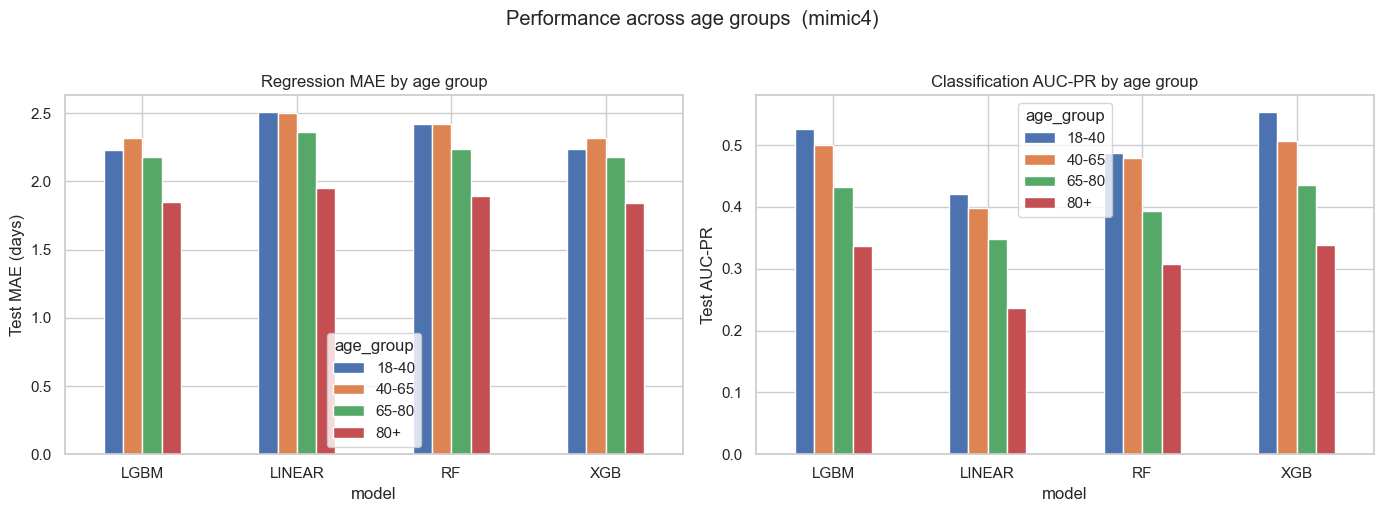

In [6]:
# Regression MAE by age group
age_rows = []
for m in MODEL_NAMES:
    pipe = reg_pipes[m]
    preds_days = to_days(pipe.predict(X_te), "regression")
    for ag in age_labels:
        mask = (te_meta_reg["age_group"] == ag).values
        if mask.sum() == 0:
            continue
        mae = mean_absolute_error(y_te_days[mask], preds_days[mask])
        actual_mean = y_te_days[mask].mean()
        age_rows.append({"model": m.upper(), "age_group": ag, "N": mask.sum(),
                         "actual_mean_LoS": actual_mean, "MAE": mae})

age_reg_df = pd.DataFrame(age_rows)
print("Regression MAE by age group:")
display(age_reg_df.pivot(index="model", columns="age_group", values="MAE").round(3))
print("\nActual mean LoS per age group:")
display(age_reg_df.pivot(index="model", columns="age_group", values="actual_mean_LoS").round(2))

age_clf_rows = []
for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    for ag in age_labels:
        mask = (te_meta_clf["age_group"] == ag).values
        if mask.sum() == 0 or len(np.unique(y_te_clf_arr[mask])) < 2:
            continue
        auc_pr = average_precision_score(y_te_clf_arr[mask], y_proba[mask])
        age_clf_rows.append({"model": m.upper(), "age_group": ag, "N": mask.sum(), "AUC_PR": auc_pr})

age_clf_df = pd.DataFrame(age_clf_rows)
print("\nClassification AUC-PR by age group:")
display(age_clf_df.pivot(index="model", columns="age_group", values="AUC_PR").round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_reg_df.pivot(index="model", columns="age_group", values="MAE").plot.bar(ax=axes[0])
axes[0].set_title("Regression MAE by age group")
axes[0].set_ylabel("Test MAE (days)")
axes[0].tick_params(axis="x", rotation=0)

age_clf_df.pivot(index="model", columns="age_group", values="AUC_PR").plot.bar(ax=axes[1])
axes[1].set_title("Classification AUC-PR by age group")
axes[1].set_ylabel("Test AUC-PR")
axes[1].tick_params(axis="x", rotation=0)

fig.suptitle(f"Performance across age groups  ({SOURCE})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"subgroup_age_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Gender performance

Fairness axis. The model should not systematically disadvantage one gender. We compare MAE and AUC-PR between male and female patients.

Regression MAE by gender:


gender,Female,Male
model,,
LGBM,2.212,2.135
LINEAR,2.367,2.326
RF,2.290,2.226
XGB,2.212,2.137



Classification AUC-PR by gender:


gender,Female,Male
model,,
LGBM,0.444,0.464
LINEAR,0.338,0.364
RF,0.422,0.426
XGB,0.455,0.467


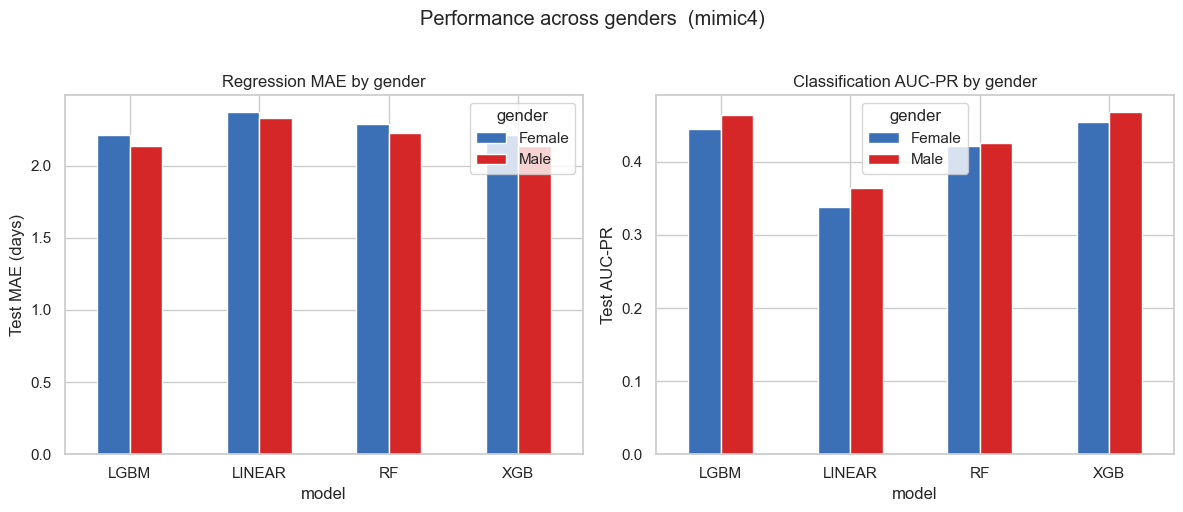

In [7]:
gender_reg_rows = []
for m in MODEL_NAMES:
    pipe = reg_pipes[m]
    preds_days = to_days(pipe.predict(X_te), "regression")
    for g_val, g_label in [("M", "Male"), ("F", "Female")]:
        mask = (te_meta_reg["gender"] == g_val).values
        if mask.sum() == 0:
            continue
        mae = mean_absolute_error(y_te_days[mask], preds_days[mask])
        gender_reg_rows.append({"model": m.upper(), "gender": g_label, "N": mask.sum(), "MAE": mae})

gender_reg_df = pd.DataFrame(gender_reg_rows)
print("Regression MAE by gender:")
display(gender_reg_df.pivot(index="model", columns="gender", values="MAE").round(3))

gender_clf_rows = []
for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    for g_val, g_label in [("M", "Male"), ("F", "Female")]:
        mask = (te_meta_clf["gender"] == g_val).values
        if mask.sum() == 0 or len(np.unique(y_te_clf_arr[mask])) < 2:
            continue
        auc_pr = average_precision_score(y_te_clf_arr[mask], y_proba[mask])
        gender_clf_rows.append({"model": m.upper(), "gender": g_label, "N": mask.sum(), "AUC_PR": auc_pr})

gender_clf_df = pd.DataFrame(gender_clf_rows)
print("\nClassification AUC-PR by gender:")
display(gender_clf_df.pivot(index="model", columns="gender", values="AUC_PR").round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender_reg_df.pivot(index="model", columns="gender", values="MAE").plot.bar(ax=axes[0], color=["#3b6fb6", "#d62728"])
axes[0].set_title("Regression MAE by gender")
axes[0].set_ylabel("Test MAE (days)")
axes[0].tick_params(axis="x", rotation=0)

gender_clf_df.pivot(index="model", columns="gender", values="AUC_PR").plot.bar(ax=axes[1], color=["#3b6fb6", "#d62728"])
axes[1].set_title("Classification AUC-PR by gender")
axes[1].set_ylabel("Test AUC-PR")
axes[1].tick_params(axis="x", rotation=0)

fig.suptitle(f"Performance across genders  ({SOURCE})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"subgroup_gender_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

## 5b. Race subgroup performance

Race is **the most critical fairness axis** in clinical AI (FDA, NIH, NEJM-AI guidelines). Healthcare models historically underperform on minority populations. We use the high-level MIMIC race categories.

**Important caveat:** MIMIC race data is self-reported at admission and aggregated into coarse categories. Small subgroups (Asian, Hispanic subcategories, etc.) may have insufficient sample size for reliable estimates.

Regression MAE by race group:


race,Asian,Black,Hispanic,Other/Unknown,White
model,,,,,
LGBM,2.094,2.286,2.120,2.730,2.004
LINEAR,2.214,2.523,2.386,2.996,2.146
RF,2.173,2.420,2.297,2.852,2.069
XGB,2.071,2.285,2.143,2.739,2.004



Sample sizes per race group:


race,Asian,Black,Hispanic,Other/Unknown,White
model,,,,,
LGBM,291,850,340,1752,6412



Classification AUC-PR by race group:


race,Asian,Black,Hispanic,Other/Unknown,White
model,,,,,
LGBM,0.506,0.480,0.549,0.501,0.428
LINEAR,0.469,0.391,0.369,0.407,0.322
RF,0.465,0.475,0.534,0.460,0.395
XGB,0.535,0.497,0.551,0.512,0.430


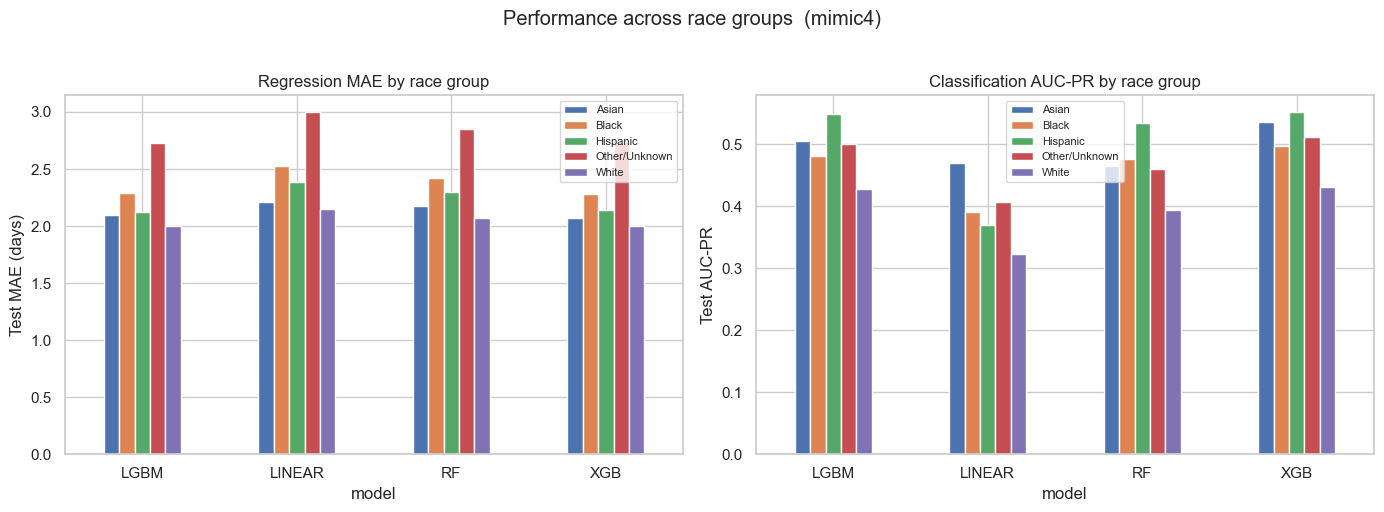

In [8]:
# Race subgroup - use the dominant MIMIC categories only (sufficient sample size)
RACE_GROUPS = {
    "White": ["WHITE", "WHITE - RUSSIAN", "WHITE - OTHER EUROPEAN", "WHITE - EASTERN EUROPEAN", "WHITE - BRAZILIAN", "PORTUGUESE"],
    "Black": ["BLACK/AFRICAN AMERICAN", "BLACK/CARIBBEAN ISLAND", "BLACK/AFRICAN", "BLACK/CAPE VERDEAN"],
    "Hispanic": ["HISPANIC OR LATINO", "HISPANIC/LATINO - PUERTO RICAN", "HISPANIC/LATINO - DOMINICAN", "HISPANIC/LATINO - MEXICAN",
                  "HISPANIC/LATINO - GUATEMALAN", "HISPANIC/LATINO - SALVADORAN", "HISPANIC/LATINO - HONDURAN",
                  "HISPANIC/LATINO - CENTRAL AMERICAN", "HISPANIC/LATINO - CUBAN", "HISPANIC/LATINO - COLUMBIAN", "SOUTH AMERICAN"],
    "Asian": ["ASIAN", "ASIAN - CHINESE", "ASIAN - SOUTH EAST ASIAN", "ASIAN - ASIAN INDIAN", "ASIAN - KOREAN"],
    "Other/Unknown": ["OTHER", "UNKNOWN", "UNABLE TO OBTAIN", "PATIENT DECLINED TO ANSWER",
                       "AMERICAN INDIAN/ALASKA NATIVE", "NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER", "MULTIPLE RACE/ETHNICITY"],
}

def _race_to_group(r):
    for g, members in RACE_GROUPS.items():
        if r in members:
            return g
    return "Other/Unknown"

te_meta_reg["race_group"] = te_meta_reg["race"].map(_race_to_group)
te_meta_clf["race_group"] = te_meta_clf["race"].map(_race_to_group)

race_labels = ["White", "Black", "Hispanic", "Asian", "Other/Unknown"]

race_reg_rows = []
for m in MODEL_NAMES:
    pipe = reg_pipes[m]
    preds_days = to_days(pipe.predict(X_te), "regression")
    for rg in race_labels:
        mask = (te_meta_reg["race_group"] == rg).values
        if mask.sum() < 50:
            continue
        mae = mean_absolute_error(y_te_days[mask], preds_days[mask])
        race_reg_rows.append({"model": m.upper(), "race": rg, "N": mask.sum(), "MAE": mae})

race_reg_df = pd.DataFrame(race_reg_rows)
print("Regression MAE by race group:")
display(race_reg_df.pivot(index="model", columns="race", values="MAE").round(3))
print("\nSample sizes per race group:")
display(race_reg_df.pivot(index="model", columns="race", values="N").iloc[:1])

race_clf_rows = []
for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    for rg in race_labels:
        mask = (te_meta_clf["race_group"] == rg).values
        if mask.sum() < 50 or len(np.unique(y_te_clf_arr[mask])) < 2:
            continue
        auc_pr = average_precision_score(y_te_clf_arr[mask], y_proba[mask])
        race_clf_rows.append({"model": m.upper(), "race": rg, "N": mask.sum(), "AUC_PR": auc_pr})

race_clf_df = pd.DataFrame(race_clf_rows)
print("\nClassification AUC-PR by race group:")
display(race_clf_df.pivot(index="model", columns="race", values="AUC_PR").round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
race_reg_df.pivot(index="model", columns="race", values="MAE").plot.bar(ax=axes[0])
axes[0].set_title("Regression MAE by race group")
axes[0].set_ylabel("Test MAE (days)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=8, loc="best")

race_clf_df.pivot(index="model", columns="race", values="AUC_PR").plot.bar(ax=axes[1])
axes[1].set_title("Classification AUC-PR by race group")
axes[1].set_ylabel("Test AUC-PR")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=8, loc="best")

fig.suptitle(f"Performance across race groups  ({SOURCE})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"subgroup_race_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

## 5c. Insurance subgroup performance

Insurance type is a **proxy for socioeconomic status** in US healthcare data. Medicaid patients tend to have lower SES, Medicare = elderly, Private = working-age insured. Differential performance across insurance types can signal SES-related bias.

Regression MAE by insurance:


insurance,Medicaid,Medicare,Other,Private
model,,,,
LGBM,2.541,2.013,2.163,2.254
LINEAR,2.757,2.167,2.334,2.450
RF,2.647,2.075,2.303,2.367
XGB,2.539,2.012,2.180,2.262



Sample sizes per insurance:


insurance,Medicaid,Medicare,Other,Private
model,,,,
LGBM,1345,5057,267,2823



Classification AUC-PR by insurance:


insurance,Medicaid,Medicare,Other,Private
model,,,,
LGBM,0.540,0.418,0.306,0.485
LINEAR,0.433,0.319,0.231,0.381
RF,0.498,0.395,0.293,0.438
XGB,0.551,0.422,0.330,0.490


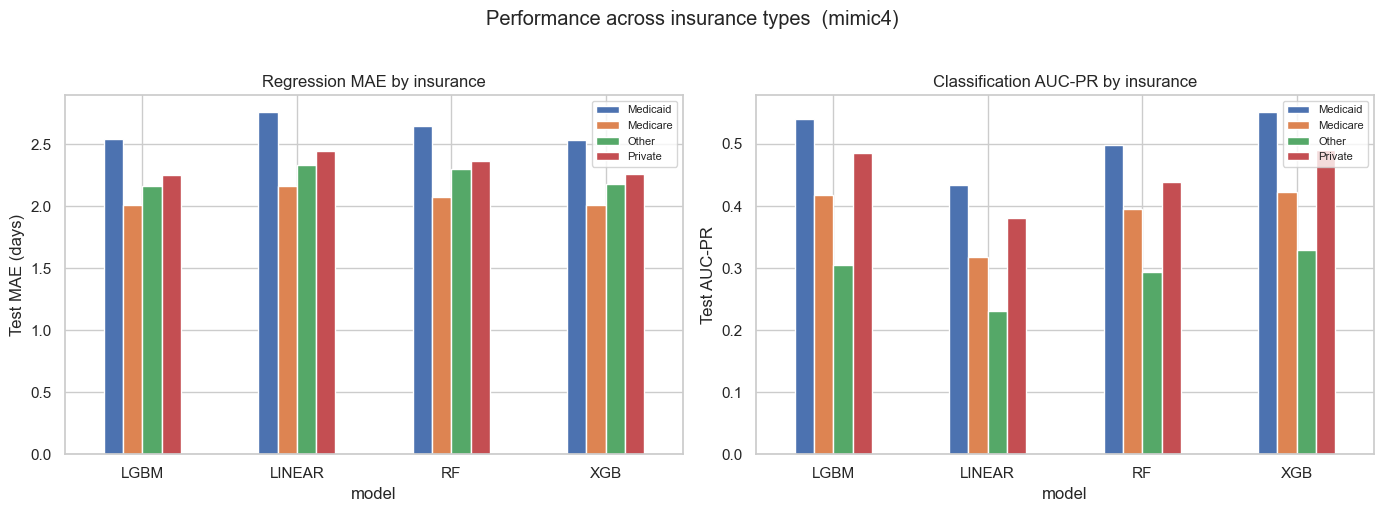

In [9]:
# Insurance subgroup (race + insurance already in te_meta_* from setup)
insurance_labels = sorted(df["insurance"].dropna().unique().tolist())

ins_reg_rows = []
for m in MODEL_NAMES:
    pipe = reg_pipes[m]
    preds_days = to_days(pipe.predict(X_te), "regression")
    for ins in insurance_labels:
        mask = (te_meta_reg["insurance"] == ins).values
        if mask.sum() < 50:
            continue
        mae = mean_absolute_error(y_te_days[mask], preds_days[mask])
        ins_reg_rows.append({"model": m.upper(), "insurance": ins, "N": mask.sum(), "MAE": mae})

ins_reg_df = pd.DataFrame(ins_reg_rows)
print("Regression MAE by insurance:")
display(ins_reg_df.pivot(index="model", columns="insurance", values="MAE").round(3))
print("\nSample sizes per insurance:")
display(ins_reg_df.pivot(index="model", columns="insurance", values="N").iloc[:1])

ins_clf_rows = []
for m in MODEL_NAMES:
    pipe = clf_pipes[m]
    y_proba = pipe.predict_proba(X_te_c)[:, 1]
    for ins in insurance_labels:
        mask = (te_meta_clf["insurance"] == ins).values
        if mask.sum() < 50 or len(np.unique(y_te_clf_arr[mask])) < 2:
            continue
        auc_pr = average_precision_score(y_te_clf_arr[mask], y_proba[mask])
        ins_clf_rows.append({"model": m.upper(), "insurance": ins, "N": mask.sum(), "AUC_PR": auc_pr})

ins_clf_df = pd.DataFrame(ins_clf_rows)
print("\nClassification AUC-PR by insurance:")
display(ins_clf_df.pivot(index="model", columns="insurance", values="AUC_PR").round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ins_reg_df.pivot(index="model", columns="insurance", values="MAE").plot.bar(ax=axes[0])
axes[0].set_title("Regression MAE by insurance")
axes[0].set_ylabel("Test MAE (days)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=8, loc="best")

ins_clf_df.pivot(index="model", columns="insurance", values="AUC_PR").plot.bar(ax=axes[1])
axes[1].set_title("Classification AUC-PR by insurance")
axes[1].set_ylabel("Test AUC-PR")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=8, loc="best")

fig.suptitle(f"Performance across insurance types  ({SOURCE})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"subgroup_insurance_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Fairness disparity table

Single summary table: for each model, the **maximum-minimum performance gap** across subgroup axes. A large disparity (e.g., MAE differs by >0.5 d between age groups) is a fairness red flag.

**Rule of thumb:** disparity < 10 % of overall metric = acceptable. > 20 % = needs investigation.

Fairness disparity table - max-min performance gap per subgroup axis:



,reg_MAE_sepsis_gap,reg_MAE_age_gap,reg_MAE_gender_gap,reg_MAE_race_gap,reg_MAE_insurance_gap,clf_AUC_PR_sepsis_gap,clf_AUC_PR_age_gap,clf_AUC_PR_gender_gap,clf_AUC_PR_race_gap,clf_AUC_PR_insurance_gap
model,,,,,,,,,,
LINEAR,2.284,0.556,0.041,0.850,0.590,0.255,0.185,0.026,0.147,0.203
RF,2.209,0.532,0.063,0.783,0.572,0.306,0.178,0.004,0.140,0.205
XGB,2.096,0.478,0.074,0.735,0.527,0.289,0.215,0.013,0.121,0.221
LGBM,2.096,0.471,0.077,0.725,0.527,0.289,0.190,0.020,0.120,0.235



Saved to reports/tables/fairness_disparity_mimic4.csv


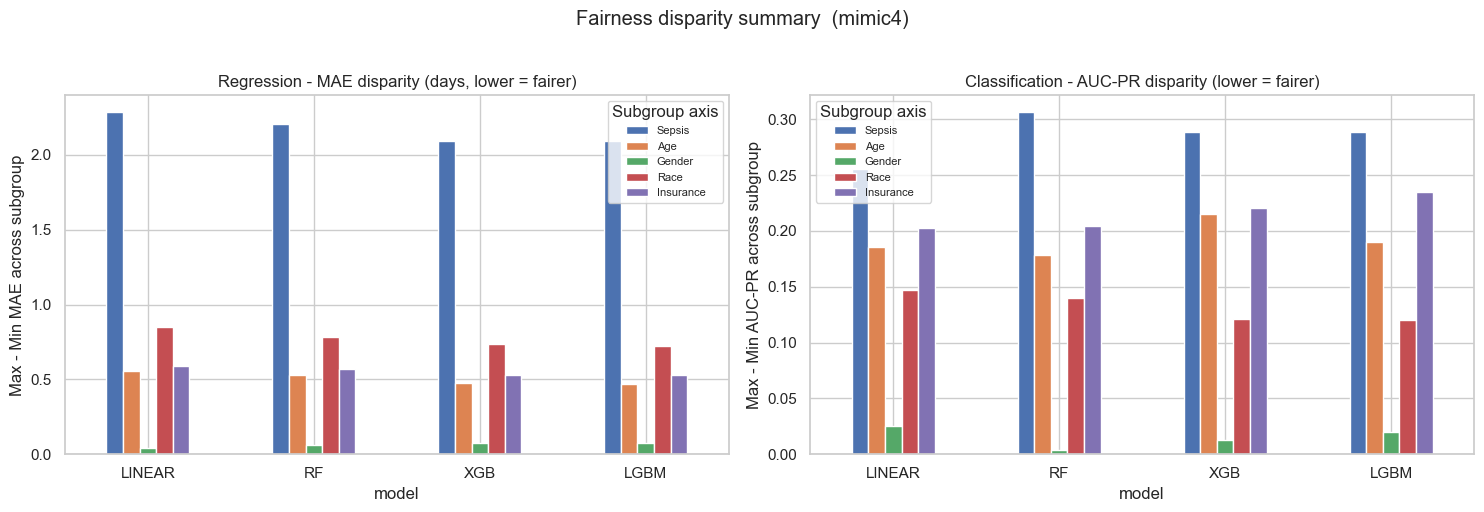

In [10]:
disparity_rows = []
for m in MODEL_NAMES:
    M = m.upper()
    # Regression MAE disparities across all subgroup axes
    reg_sepsis = reg_df[reg_df["model"] == M].set_index("subgroup")["MAE"]
    reg_age = age_reg_df[age_reg_df["model"] == M].set_index("age_group")["MAE"]
    reg_gender = gender_reg_df[gender_reg_df["model"] == M].set_index("gender")["MAE"]
    reg_race = race_reg_df[race_reg_df["model"] == M].set_index("race")["MAE"]
    reg_ins = ins_reg_df[ins_reg_df["model"] == M].set_index("insurance")["MAE"]
    # Classification AUC-PR disparities
    clf_sepsis = clf_df[clf_df["model"] == M].set_index("subgroup")["AUC_PR"]
    clf_age = age_clf_df[age_clf_df["model"] == M].set_index("age_group")["AUC_PR"]
    clf_gender = gender_clf_df[gender_clf_df["model"] == M].set_index("gender")["AUC_PR"]
    clf_race = race_clf_df[race_clf_df["model"] == M].set_index("race")["AUC_PR"]
    clf_ins = ins_clf_df[ins_clf_df["model"] == M].set_index("insurance")["AUC_PR"]

    disparity_rows.append({
        "model": M,
        "reg_MAE_sepsis_gap": reg_sepsis.max() - reg_sepsis.min(),
        "reg_MAE_age_gap": reg_age.max() - reg_age.min(),
        "reg_MAE_gender_gap": reg_gender.max() - reg_gender.min(),
        "reg_MAE_race_gap": reg_race.max() - reg_race.min(),
        "reg_MAE_insurance_gap": reg_ins.max() - reg_ins.min(),
        "clf_AUC_PR_sepsis_gap": clf_sepsis.max() - clf_sepsis.min(),
        "clf_AUC_PR_age_gap": clf_age.max() - clf_age.min(),
        "clf_AUC_PR_gender_gap": clf_gender.max() - clf_gender.min(),
        "clf_AUC_PR_race_gap": clf_race.max() - clf_race.min(),
        "clf_AUC_PR_insurance_gap": clf_ins.max() - clf_ins.min(),
    })

disparity_df = pd.DataFrame(disparity_rows).set_index("model")
print("Fairness disparity table - max-min performance gap per subgroup axis:\n")
display(disparity_df.round(3))

disparity_df.round(3).to_csv(FIGURES_DIR.parent / "tables" / f"fairness_disparity_{SOURCE}.csv")
print(f"\nSaved to reports/tables/fairness_disparity_{SOURCE}.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
reg_gaps = disparity_df[["reg_MAE_sepsis_gap", "reg_MAE_age_gap", "reg_MAE_gender_gap",
                          "reg_MAE_race_gap", "reg_MAE_insurance_gap"]]
reg_gaps.columns = ["Sepsis", "Age", "Gender", "Race", "Insurance"]
reg_gaps.plot.bar(ax=axes[0])
axes[0].set_title("Regression - MAE disparity (days, lower = fairer)")
axes[0].set_ylabel("Max - Min MAE across subgroup")
axes[0].legend(title="Subgroup axis", fontsize=8)
axes[0].tick_params(axis="x", rotation=0)

clf_gaps = disparity_df[["clf_AUC_PR_sepsis_gap", "clf_AUC_PR_age_gap", "clf_AUC_PR_gender_gap",
                          "clf_AUC_PR_race_gap", "clf_AUC_PR_insurance_gap"]]
clf_gaps.columns = ["Sepsis", "Age", "Gender", "Race", "Insurance"]
clf_gaps.plot.bar(ax=axes[1])
axes[1].set_title("Classification - AUC-PR disparity (lower = fairer)")
axes[1].set_ylabel("Max - Min AUC-PR across subgroup")
axes[1].legend(title="Subgroup axis", fontsize=8)
axes[1].tick_params(axis="x", rotation=0)

fig.suptitle(f"Fairness disparity summary  ({SOURCE})", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"fairness_disparity_{SOURCE}.png", dpi=120, bbox_inches="tight")
plt.show()